In [1]:
import sys
sys.path.append("../basic_pipelines")

In [2]:
from pymavlink_common import wait_heartbeat, auto_connect
from autopilot_companion import AutipilotCompanion
import numpy as np
import matplotlib.pyplot as plt

In [4]:
ac = AutipilotCompanion()
ac.configure(
    device="udp:192.168.1.34:14550",
    angularcs_lib_path="/home/udaiadmin/Projects/hailo-target-tracker/resources/angularcs.so"
)

Loading shared lib: /home/udaiadmin/Projects/hailo-target-tracker/resources/angularcs.so
Connecting message: None
Connecting message: AHRS {omegaIx : -0.002821152564138174, omegaIy : -0.0032043030951172113, omegaIz : -0.0028633426409214735, accel_weight : 0.0, renorm_val : 0.0, error_rp : 0.00823142472654581, error_yaw : 0.02168075367808342}


In [18]:
help(ac.master.mav.set_attitude_target_send)

type(ac.master.mav)

Help on method set_attitude_target_send in module pymavlink.dialects.v20.ardupilotmega:

set_attitude_target_send(time_boot_ms: int, target_system: int, target_component: int, type_mask: int, q: Sequence[float], body_roll_rate: float, body_pitch_rate: float, body_yaw_rate: float, thrust: float, force_mavlink1: bool = False) -> None method of pymavlink.dialects.v20.ardupilotmega.MAVLink instance
    Sets a desired vehicle attitude. Used by an external controller to
    command the vehicle (manual controller or other system).
    
    time_boot_ms              : Timestamp (time since system boot). [ms] (type:uint32_t)
    target_system             : System ID (type:uint8_t)
    target_component          : Component ID (type:uint8_t)
    type_mask                 : Bitmap to indicate which dimensions should be ignored by the vehicle. (type:uint8_t, values:ATTITUDE_TARGET_TYPEMASK)
    q                         : Attitude quaternion (w, x, y, z order, zero-rotation is 1, 0, 0, 0) (type:flo

pymavlink.dialects.v20.ardupilotmega.MAVLink

In [8]:
import pymavlink.dialects.v20.ardupilotmega as dial


In [12]:

with open("outfile.txt", "w") as outfile:
    outfile.write("\n".join(str(item) for item in dir(dial)))

In [ ]:
dir(dial.MAVLink.)

['_MAVLink__callbacks',
 '_MAVLink__parse_char_legacy',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'actuator_control_target_encode',
 'actuator_control_target_send',
 'actuator_output_status_encode',
 'actuator_output_status_send',
 'adap_tuning_encode',
 'adap_tuning_send',
 'adsb_vehicle_encode',
 'adsb_vehicle_send',
 'ahrs2_encode',
 'ahrs2_send',
 'ahrs3_encode',
 'ahrs3_send',
 'ahrs_encode',
 'ahrs_send',
 'airlink_auth_encode',
 'airlink_auth_response_encode',
 'airlink_auth_response_send',
 'airlink_auth_send',
 'airspeed_autocal_encode',
 'airspeed_autocal_send',
 'ais_vessel_encode',
 'ais_vessel_send',
 'altitude_encode',
 'altitude_se

In [44]:
import time
from pymavlink import mavutil
from pymavlink import quaternion

In [49]:
heading = 50

x_m = float(100)
y_m = float(50)
z_m = float(10)



try:
    # m = ac.master.recv_match(
    #     type='ATTITUDE',
    #     blocking=True,
    #     timeout=0.02)

    # if m:
    # ac.master.mav.set_position_target_local_ned_send(
    #     int(1e3 * (time.time() - ac.boot_time)),
    #     ac.master.target_system,
    #     ac.master.target_component,
    #     8,  # coordinate frame MAV_FRAME_BODY_NED
    #     3576,     # type mask (pos only)
    #     x_m, y_m, z_m,  # position x,y,z
    #     0, 0, 0,  # velocity x,y,z
    #     0, 0, 0,  # accel x,y,z
    #     0, 0
    # )
        
    # ac.master.mav.set_position_target_local_ned_send(
    #     int(1e3 * (time.time() - ac.boot_time)),
    #     ac.master.target_system,
    #     ac.master.target_component,
    #     8,  # coordinate frame MAV_FRAME_BODY_NED
    #     3576,     # type mask (pos only)
    #     0, 0, 0,  # position x,y,z
    #     0, 0, 0,  # velocity x,y,z
    #     0, 0, 0,  # accel x,y,z
    #     40, 0
    # )
        
    # ac.master.mav.command_long_send(
    #     ac.master.target_system,  # target_system
    #     ac.master.target_component,  # target_component
    #     mavutil.mavlink.MAV_CMD_CONDITION_YAW,  # command
    #     0,  # confirmation
    #     -10,  # param1 (angle value)
    #     0,  # param2 (angular speed value)
    #     0,  # param3
    #     0,  # param4 (mode: 0->absolute / 1->relative)
    #     0,  # param5
    #     0,  # param6
    #     0)  # param7
        
    q = quaternion.Quaternion([0, 45, 10])
    ac.master.mav.set_attitude_target_send(
        int(1e3 * (time.time() - ac.boot_time)),
        ac.master.target_system,
        ac.master.target_component,
        ac.typemask_ypr_throttle,
        q,
        0,  # roll rate, not used in AP
        0,  # pitch rate, not used in AP
        0,  # yaw rate, not used in AP
        100)
    

except Exception as e:
    print(
        f"Error setting heading: \n   - heading: {heading}\n {e}")

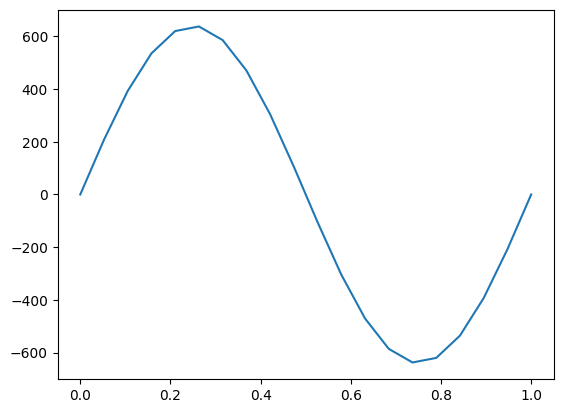

In [4]:
f = 1.
w = 2. * np.pi * f
time_interval = 1
samples = 20
t = np.linspace(0, time_interval, samples)
y = np.sin(w * t) * 640
plt.plot(t, y)
plt.show()

In [5]:
print(np.round(y, 0))

[   0.  208.  393.  536.  620.  638.  586.  471.  305.  105. -105. -305.
 -471. -586. -638. -620. -536. -393. -208.   -0.]


In [12]:
for x_bias in np.nditer(np.round(y, 0)):
    v = ac.cac.control_angular_motion_ex(0, 0, 0, 0.1, 640, 640, 60, 60)
    print(
        f"yaw:{v.control_output_x}, pitch:{v.control_output_y}, roll:{v.control_output_z}")

yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.14

In [13]:
v = ac.cac.control_angular_motion_ex(0, 0, 0, 0.1, 640, 640, 60, 60)
print(
        f"yaw:{v.control_output_x}, pitch:{v.control_output_y}, roll:{v.control_output_z}")
v = ac.cac.control_angular_motion_ex(0, 0, 0, 0.1, 640, 640, 60, 60)
print(
    f"yaw:{v.control_output_x}, pitch:{v.control_output_y}, roll:{v.control_output_z}")
v = ac.cac.control_angular_motion_ex(0, 0, 0, 0.1, 640, 640, 60, 60)
print(
    f"yaw:{v.control_output_x}, pitch:{v.control_output_y}, roll:{v.control_output_z}")

yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
yaw:-0.47903233766555786, pitch:-0.47903233766555786, roll:-3.141592502593994
